# Photonic Quantum Error Correction: BB84 QKD Performance Analysis
## Cat (Bosonic) Qubits vs. Standard (Noisy) Qubits

**Course:** Quantum Simulation & Computing Lab  
**Topic:** Simulating Alice & Bob (Cat/Bosonic) qubit noise bias using Qiskit noise models

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    depolarizing_error,
    pauli_error,
    amplitude_damping_error,
    phase_damping_error,
)
from qiskit.compiler import transpile

plt.rcParams.update({
    'figure.facecolor':  '#0d1117',
    'axes.facecolor':    '#0d1117',
    'axes.edgecolor':    '#30363d',
    'axes.labelcolor':   '#c9d1d9',
    'xtick.color':       '#8b949e',
    'ytick.color':       '#8b949e',
    'text.color':        '#c9d1d9',
    'grid.color':        '#21262d',
    'grid.linestyle':    '--',
    'grid.alpha':        0.6,
    'font.family':       'monospace',
    'axes.titleweight':  'bold',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'legend.facecolor':  '#161b22',
    'legend.edgecolor':  '#30363d',
    'figure.dpi':        120,
})

ACCENT_BLUE   = '#58a6ff'
ACCENT_TEAL   = '#39d353'
ACCENT_ORANGE = '#f78166'
ACCENT_YELLOW = '#e3b341'

print("Imports complete")

✓ Imports complete


In [ ]:
def build_standard_noise_model(p_total: float) -> NoiseModel:
    """
    Standard qubit: symmetric depolarizing noise.
    Equal probability p_total/3 for X, Y, Z errors on each gate and measurement.
    """
    nm = NoiseModel()
    gate_err = depolarizing_error(p_total, 1)
    nm.add_all_qubit_quantum_error(gate_err, ['h', 'x', 'z', 's', 'sdg'])
    p_meas = p_total / 2
    nm.add_all_qubit_readout_error([[1 - p_meas, p_meas], [p_meas, 1 - p_meas]])
    return nm


def build_cat_noise_model(p_total: float, kappa: float) -> NoiseModel:
    """
    Cat qubit PROXY: biased Pauli channel.
    k = p_Z / p_X  (phase-flip bias over bit-flip)
    
    Given total error rate p_total and bias k:
        p_X = p_Y = p_total / (2*(k + 1))
        p_Z = p_total * k / (k + 1)
        p_I = 1 - p_X - p_Y - p_Z
    
    At k=1 this reduces to depolarizing. At k>>1, X errors vanish.
    """
    p_x = p_total / (2 * (kappa + 1))
    p_y = p_x
    p_z = p_total * kappa / (kappa + 1)
    p_i = max(0.0, 1.0 - p_x - p_y - p_z)

    total = p_i + p_x + p_y + p_z
    p_i, p_x, p_y, p_z = p_i/total, p_x/total, p_y/total, p_z/total

    gate_err = pauli_error([('I', p_i), ('X', p_x), ('Y', p_y), ('Z', p_z)])
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(gate_err, ['h', 'x', 'z', 's', 'sdg'])

    p_meas_bitflip = (p_total / 2) / (kappa + 1)
    
    p_meas_bitflip = min(p_meas_bitflip, 0.499)
    nm.add_all_qubit_readout_error(
        [[1 - p_meas_bitflip, p_meas_bitflip],
         [p_meas_bitflip, 1 - p_meas_bitflip]]
    )
    return nm

def noise_model_summary(p_total: float, kappa: float):
    """Print a side-by-side summary of error rates for both models."""
    p_x_std = p_total / 3
    p_z_std = p_total / 3
    p_x_cat = p_total / (2 * (kappa + 1))
    p_z_cat = p_total * kappa / (kappa + 1)
    print(f"Noise Model Summary  |  p_total={p_total:.4f}  k={kappa}")
    print(f"{'Error type':<18} {'Standard':>12} {'Cat (proxy)':>14}")
    print(f"{'p_X (bit-flip)':<18} {p_x_std:>12.6f} {p_x_cat:>14.6f}")
    print(f"{'p_Z (phase-flip)':<18} {p_z_std:>12.6f} {p_z_cat:>14.6f}")
    print(f"{'Bias ratio k_eff':<18} {'1.0':>12} {p_z_cat/max(p_x_cat,1e-12):>14.1f}")

noise_model_summary(p_total=0.05, kappa=100)
print("\nNoise models built")

  Noise Model Summary  |  p_total=0.0500  κ=100
  Error type             Standard    Cat (proxy)
  ----------------------------------------------
  p_X (bit-flip)         0.016667       0.000248
  p_Z (phase-flip)       0.016667       0.049505
  Bias ratio κ_eff            1.0          200.0

✓ Noise models built


In [ ]:
def build_bb84_circuit(alice_bit: int, alice_basis: int, bob_basis: int) -> QuantumCircuit:
    """
    Build a single BB84 qubit transmission circuit.

    alice_bit   : 0 or 1
    alice_basis : 0 = Z-basis (rectilinear), 1 = X-basis (diagonal)
    bob_basis   : 0 = Z-basis,               1 = X-basis

    Encoding:
        Z-basis: |0⟩ → bit 0, |1⟩ → bit 1
        X-basis: |+⟩ → bit 0, |−⟩ → bit 1
    """
    qc = QuantumCircuit(1, 1)

    if alice_bit == 1:
        qc.x(0)
    if alice_basis == 1:
        qc.h(0)
    if bob_basis == 1:
        qc.h(0)
    qc.measure(0, 0)

    return qc

def run_bb84_simulation(
    noise_model: NoiseModel,
    n_qubits: int = 2000,
    shots_per_qubit: int = 1,
    seed: int = 42
) -> dict:
    """
    Simulate a full BB84 protocol run with a given noise model.

    Returns a dict with:
        - qber           : Quantum Bit Error Rate on sifted key
        - sift_rate      : Fraction of bits surviving sifting
        - n_sifted       : Number of sifted bits
        - secure_key_len : Estimated secure key bits (Devetak-Winter bound)
        - alice_bits, alice_bases, bob_bases, bob_results
    """
    rng = np.random.default_rng(seed)
    backend = AerSimulator(noise_model=noise_model)

    alice_bits   = rng.integers(0, 2, n_qubits)
    alice_bases  = rng.integers(0, 2, n_qubits)
    bob_bases    = rng.integers(0, 2, n_qubits)
    bob_results  = np.zeros(n_qubits, dtype=int)

    circuits = [
        build_bb84_circuit(int(alice_bits[i]), int(alice_bases[i]), int(bob_bases[i]))
        for i in range(n_qubits)
    ]
    tcirc = transpile(circuits, backend, optimization_level=0)
    job = backend.run(tcirc, shots=1)
    results = job.result()

    for i, circ in enumerate(circuits):
        counts = results.get_counts(i)
        bob_results[i] = int(max(counts, key=counts.get))

    sifted_mask  = alice_bases == bob_bases
    sifted_alice = alice_bits[sifted_mask]
    sifted_bob   = bob_results[sifted_mask]

    n_sifted   = len(sifted_alice)
    errors     = np.sum(sifted_alice != sifted_bob)
    qber       = errors / n_sifted if n_sifted > 0 else 1.0
    sift_rate  = n_sifted / n_qubits

    def h2(p):
        if p <= 0 or p >= 1:
            return 0.0
        return -p * np.log2(p) - (1 - p) * np.log2(1 - p)
    
    raw_key_rate = max(0.0, 1.0 - 2 * h2(qber))
    secure_key_len = int(n_sifted * raw_key_rate)

    return {
        'qber':           qber,
        'sift_rate':      sift_rate,
        'n_sifted':       n_sifted,
        'secure_key_len': secure_key_len,
        'key_rate':       raw_key_rate,
        'alice_bits':     alice_bits,
        'alice_bases':    alice_bases,
        'bob_bases':      bob_bases,
        'bob_results':    bob_results,
        'sifted_mask':    sifted_mask,
    }

print("BB84 circuit and simulation functions defined")

✓ BB84 circuit and simulation functions defined


In [ ]:
P_TOTAL  = 0.05
KAPPA    = 100 
N_QUBITS = 2000

print(f"Running BB84 with p_total={P_TOTAL}, k={KAPPA}, N={N_QUBITS} qubits\n")

nm_std = build_standard_noise_model(P_TOTAL)
nm_cat = build_cat_noise_model(P_TOTAL, KAPPA)

print("Simulating standard qubits")
res_std = run_bb84_simulation(nm_std, n_qubits=N_QUBITS, seed=42)

print("Simulating cat qubits (k={})".format(KAPPA))
res_cat = run_bb84_simulation(nm_cat, n_qubits=N_QUBITS, seed=42)

BB84_THRESHOLD = 0.11

def print_results(label, res):
    secure = 'SECURE' if res['qber'] < BB84_THRESHOLD else 'INSECURE'
    print(f"{'─'*42}")
    print(f"{label}")
    print(f"{'─'*42}")
    print(f"QBER: {res['qber']:.4f}  ({res['qber']*100:.2f}%)  {secure}")
    print(f"Sifted bits: {res['n_sifted']} / {N_QUBITS}  (sift rate {res['sift_rate']:.2%})")
    print(f"Key rate (DW): {res['key_rate']:.4f} bits/sifted bit")
    print(f"Secure key length: {res['secure_key_len']} bits")

print()
print_results('Standard Qubit (depolarizing)', res_std)
print()
print_results(f'Cat Qubit proxy (k={KAPPA})', res_cat)
print(f"{'─'*42}")
print(f"\nQBER reduction factor: {res_std['qber'] / max(res_cat['qber'], 1e-9):.1f}×")
print(f"Key length gain: {res_cat['secure_key_len'] - res_std['secure_key_len']:+d} bits")

Running BB84 with p_total=0.05, κ=100, N=2000 qubits...

[1/2] Simulating standard qubits...
[2/2] Simulating cat qubits (κ=100)...

  ──────────────────────────────────────────
  Standard Qubit (depolarizing)
  ──────────────────────────────────────────
  QBER              : 0.0538  (5.38%)  ✓ SECURE
  Sifted bits       : 966 / 2000  (sift rate 48.30%)
  Key rate (DW)     : 0.3951 bits/sifted bit
  Secure key length : 381 bits

  ──────────────────────────────────────────
  Cat Qubit proxy (κ=100)
  ──────────────────────────────────────────
  QBER              : 0.0342  (3.42%)  ✓ SECURE
  Sifted bits       : 966 / 2000  (sift rate 48.30%)
  Key rate (DW)     : 0.5703 bits/sifted bit
  Secure key length : 550 bits
  ──────────────────────────────────────────

  QBER reduction factor : 1.6×
  Key length gain       : +169 bits


In [ ]:
P_TOTAL_SWEEP = 0.06
N_QUBITS_SWEEP = 1500
N_TRIALS = 3

KAPPA_VALUES = np.unique(np.round(
    np.concatenate([
        np.logspace(0, 1, 6),
        np.logspace(1, 2, 8),
        np.logspace(2, 3, 8),
        np.logspace(3, 4, 5),
    ])
).astype(int))

print(f"k values to sweep ({len(KAPPA_VALUES)} points): {KAPPA_VALUES}")
print(f"Total circuits: {len(KAPPA_VALUES) * N_TRIALS * N_QUBITS_SWEEP:,}\n")

qber_std_list, key_std_list = [], []
for trial in range(N_TRIALS):
    nm = build_standard_noise_model(P_TOTAL_SWEEP)
    r = run_bb84_simulation(nm, n_qubits=N_QUBITS_SWEEP, seed=trial)
    qber_std_list.append(r['qber'])
    key_std_list.append(r['secure_key_len'])

qber_std_mean = np.mean(qber_std_list)
qber_std_std  = np.std(qber_std_list)
key_std_mean  = np.mean(key_std_list)

print(f"Standard qubit baseline: QBER = {qber_std_mean:.4f} ± {qber_std_std:.4f}")

sweep_results = []

for idx, kappa in enumerate(KAPPA_VALUES):
    qber_trials, key_trials = [], []
    for trial in range(N_TRIALS):
        nm = build_cat_noise_model(P_TOTAL_SWEEP, float(kappa))
        r  = run_bb84_simulation(nm, n_qubits=N_QUBITS_SWEEP, seed=trial+100)
        qber_trials.append(r['qber'])
        key_trials.append(r['secure_key_len'])

    qber_mean = np.mean(qber_trials)
    qber_err  = np.std(qber_trials)
    key_mean  = np.mean(key_trials)

    sweep_results.append({
        'kappa':     kappa,
        'qber_mean': qber_mean,
        'qber_err':  qber_err,
        'key_mean':  key_mean,
    })

    print(f"  k = {kappa:>6}  |  QBER = {qber_mean:.4f} ± {qber_err:.4f}  |  key ≈ {int(key_mean)} bits")

print("\n k sweep complete")

κ values to sweep (24 points): [    1     2     3     4     6    10    14    19    27    37    52    72
   100   139   193   268   373   518   720  1000  1778  3162  5623 10000]
Total circuits: 108,000

Standard qubit baseline: QBER = 0.0669 ± 0.0011
  κ =      1  |  QBER = 0.0656 ± 0.0003  |  key ≈ 223 bits
  κ =      2  |  QBER = 0.0539 ± 0.0024  |  key ≈ 292 bits
  κ =      3  |  QBER = 0.0402 ± 0.0081  |  key ≈ 383 bits
  κ =      4  |  QBER = 0.0467 ± 0.0042  |  key ≈ 337 bits
  κ =      6  |  QBER = 0.0401 ± 0.0042  |  key ≈ 382 bits
  κ =     10  |  QBER = 0.0370 ± 0.0056  |  key ≈ 404 bits
  κ =     14  |  QBER = 0.0372 ± 0.0048  |  key ≈ 401 bits
  κ =     19  |  QBER = 0.0310 ± 0.0064  |  key ≈ 446 bits
  κ =     27  |  QBER = 0.0340 ± 0.0052  |  key ≈ 423 bits
  κ =     37  |  QBER = 0.0252 ± 0.0047  |  key ≈ 490 bits
  κ =     52  |  QBER = 0.0327 ± 0.0049  |  key ≈ 433 bits
  κ =     72  |  QBER = 0.0278 ± 0.0038  |  key ≈ 469 bits
  κ =    100  |  QBER = 0.0282 ± 0.0121  

In [ ]:
KAPPA_FIXED   = 200
P_VALUES      = np.linspace(0.01, 0.25, 18)
N_QUBITS_P    = 1500
N_TRIALS_P    = 3

print(f"Sweeping p_total from {P_VALUES[0]:.2f} to {P_VALUES[-1]:.2f} | k_cat={KAPPA_FIXED}\n")

p_sweep_std, p_sweep_cat = [], []

for p in P_VALUES:
    q_std, q_cat = [], []
    for trial in range(N_TRIALS_P):
        nm_s = build_standard_noise_model(p)
        nm_c = build_cat_noise_model(p, KAPPA_FIXED)
        r_s = run_bb84_simulation(nm_s, N_QUBITS_P, seed=trial)
        r_c = run_bb84_simulation(nm_c, N_QUBITS_P, seed=trial)
        q_std.append(r_s['qber'])
        q_cat.append(r_c['qber'])

    p_sweep_std.append({'p': p, 'qber': np.mean(q_std), 'err': np.std(q_std)})
    p_sweep_cat.append({'p': p, 'qber': np.mean(q_cat), 'err': np.std(q_cat)})
    print(f"p={p:.3f}  | std QBER={np.mean(q_std):.4f}  cat QBER={np.mean(q_cat):.4f}")

print("\nNoise level sweep complete")

Sweeping p_total from 0.01 to 0.25 | κ_cat=200

  p=0.010  | std QBER=0.0081  cat QBER=0.0027
  p=0.024  | std QBER=0.0312  cat QBER=0.0153
  p=0.038  | std QBER=0.0417  cat QBER=0.0267
  p=0.052  | std QBER=0.0619  cat QBER=0.0176
  p=0.066  | std QBER=0.0747  cat QBER=0.0339
  p=0.081  | std QBER=0.0957  cat QBER=0.0398
  p=0.095  | std QBER=0.1085  cat QBER=0.0466
  p=0.109  | std QBER=0.1145  cat QBER=0.0505
  p=0.123  | std QBER=0.1354  cat QBER=0.0674
  p=0.137  | std QBER=0.1556  cat QBER=0.0653
  p=0.151  | std QBER=0.1759  cat QBER=0.0808
  p=0.165  | std QBER=0.1741  cat QBER=0.0785
  p=0.179  | std QBER=0.1974  cat QBER=0.0874
  p=0.194  | std QBER=0.1875  cat QBER=0.0962
  p=0.208  | std QBER=0.2254  cat QBER=0.0968
  p=0.222  | std QBER=0.2139  cat QBER=0.1075
  p=0.236  | std QBER=0.2333  cat QBER=0.1210
  p=0.250  | std QBER=0.2224  cat QBER=0.1254

✓ Noise level sweep complete


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/plot1_kappa_sweep.png'

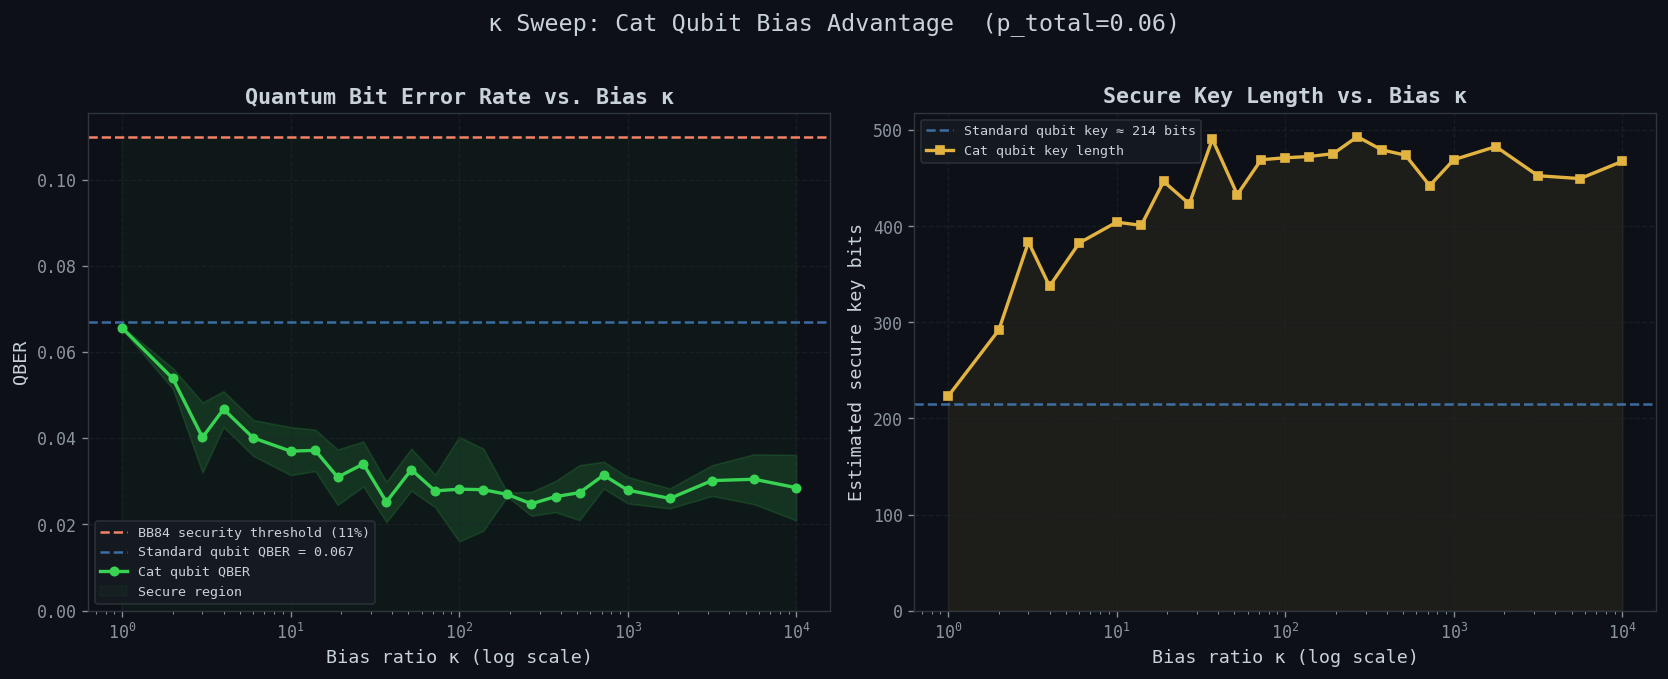

In [ ]:
kappas     = [r['kappa']     for r in sweep_results]
qber_means = [r['qber_mean'] for r in sweep_results]
qber_errs  = [r['qber_err']  for r in sweep_results]
key_means  = [r['key_mean']  for r in sweep_results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(f'k Sweep: Cat Qubit Bias Advantage  (p_total={P_TOTAL_SWEEP})',
             fontsize=14, color='#c9d1d9', y=1.02)

ax1.set_xscale('log')
ax1.axhline(BB84_THRESHOLD, color=ACCENT_ORANGE, lw=1.5, ls='--', label='BB84 security threshold (11%)')
ax1.axhline(qber_std_mean, color=ACCENT_BLUE, lw=1.5, ls='--', alpha=0.6,
            label=f'Standard qubit QBER = {qber_std_mean:.3f}')
ax1.fill_between(kappas,
                 np.array(qber_means) - np.array(qber_errs),
                 np.array(qber_means) + np.array(qber_errs),
                 color=ACCENT_TEAL, alpha=0.15)
ax1.plot(kappas, qber_means, 'o-', color=ACCENT_TEAL, lw=2, ms=5, label='Cat qubit QBER')

ax1.fill_between([min(kappas), max(kappas)], 0, BB84_THRESHOLD,
                 color=ACCENT_TEAL, alpha=0.04, label='Secure region')

ax1.set_xlabel('Bias ratio k (log scale)')
ax1.set_ylabel('QBER')
ax1.set_title('Quantum Bit Error Rate vs. Bias k')
ax1.legend(fontsize=8)
ax1.grid(True)
ax1.set_ylim(bottom=0)

ax2.set_xscale('log')
ax2.axhline(key_std_mean, color=ACCENT_BLUE, lw=1.5, ls='--', alpha=0.6,
            label=f'Standard qubit key ≈ {int(key_std_mean)} bits')
ax2.plot(kappas, key_means, 's-', color=ACCENT_YELLOW, lw=2, ms=5, label='Cat qubit key length')
ax2.fill_between(kappas, 0, key_means, color=ACCENT_YELLOW, alpha=0.08)

ax2.set_xlabel('Bias ratio k (log scale)')
ax2.set_ylabel('Estimated secure key bits')
ax2.set_title('Secure Key Length vs. Bias k')
ax2.legend(fontsize=8)
ax2.grid(True)
ax2.set_ylim(bottom=0)

fig.tight_layout()
plt.savefig('plot1_kappa_sweep.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("Plot 1 saved")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/plot2_noise_sweep.png'

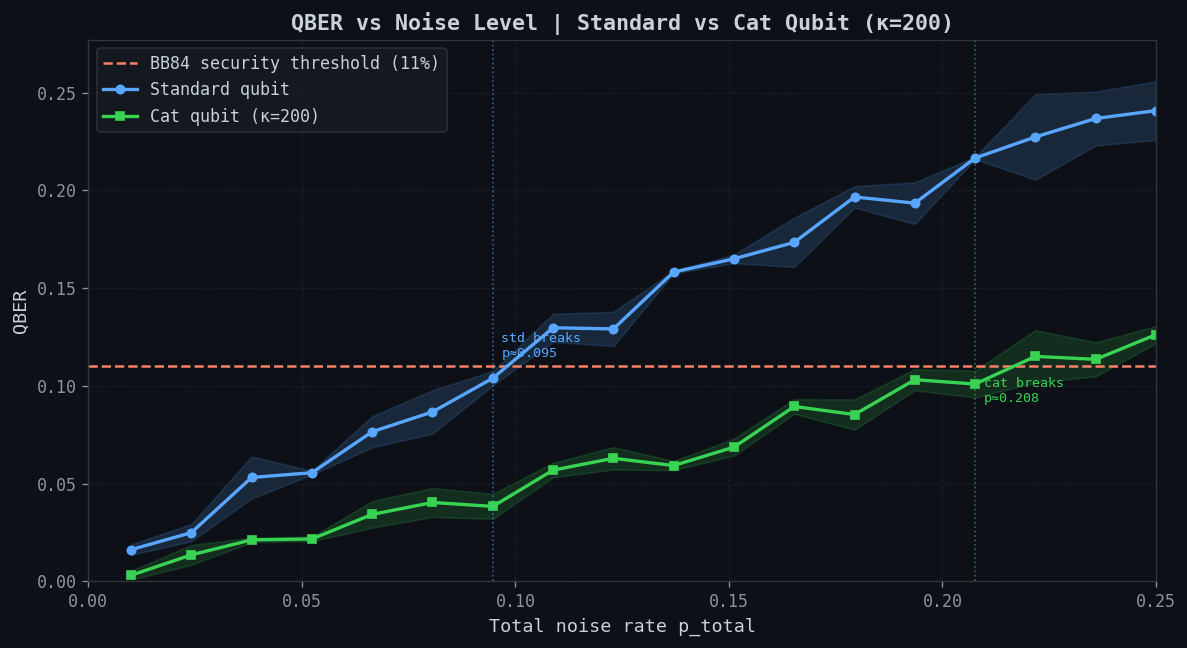

In [ ]:
p_vals     = [r['p']    for r in p_sweep_std]
qber_std_p = [r['qber'] for r in p_sweep_std]
qber_std_e = [r['err']  for r in p_sweep_std]
qber_cat_p = [r['qber'] for r in p_sweep_cat]
qber_cat_e = [r['err']  for r in p_sweep_cat]

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.axhline(BB84_THRESHOLD, color=ACCENT_ORANGE, lw=1.5, ls='--', label='BB84 security threshold (11%)')

ax.fill_between(p_vals,
    np.array(qber_std_p) - np.array(qber_std_e),
    np.array(qber_std_p) + np.array(qber_std_e),
    color=ACCENT_BLUE, alpha=0.15)
ax.plot(p_vals, qber_std_p, 'o-', color=ACCENT_BLUE, lw=2, ms=5, label='Standard qubit')

ax.fill_between(p_vals,
    np.array(qber_cat_p) - np.array(qber_cat_e),
    np.array(qber_cat_p) + np.array(qber_cat_e),
    color=ACCENT_TEAL, alpha=0.15)
ax.plot(p_vals, qber_cat_p, 's-', color=ACCENT_TEAL, lw=2, ms=5, label=f'Cat qubit (k={KAPPA_FIXED})')

for i in range(len(p_vals)-1):
    if qber_std_p[i] < BB84_THRESHOLD and qber_std_p[i+1] >= BB84_THRESHOLD:
        ax.axvline(p_vals[i], color=ACCENT_BLUE, lw=1, ls=':', alpha=0.5)
        ax.text(p_vals[i]+0.002, BB84_THRESHOLD+0.005, f'std breaks\np≈{p_vals[i]:.3f}',
                color=ACCENT_BLUE, fontsize=8)
    if qber_cat_p[i] < BB84_THRESHOLD and qber_cat_p[i+1] >= BB84_THRESHOLD:
        ax.axvline(p_vals[i], color=ACCENT_TEAL, lw=1, ls=':', alpha=0.5)
        ax.text(p_vals[i]+0.002, BB84_THRESHOLD-0.018, f'cat breaks\np≈{p_vals[i]:.3f}',
                color=ACCENT_TEAL, fontsize=8)

ax.set_xlabel('Total noise rate p_total')
ax.set_ylabel('QBER')
ax.set_title(f'QBER vs Noise Level | Standard vs Cat Qubit (k={KAPPA_FIXED})')
ax.legend()
ax.grid(True)
ax.set_xlim(0, max(p_vals))
ax.set_ylim(0, max(max(qber_std_p), max(qber_cat_p)) * 1.15)

fig.tight_layout()
plt.savefig('plot2_noise_sweep.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("Plot 2 saved")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/plot3_heatmap.png'

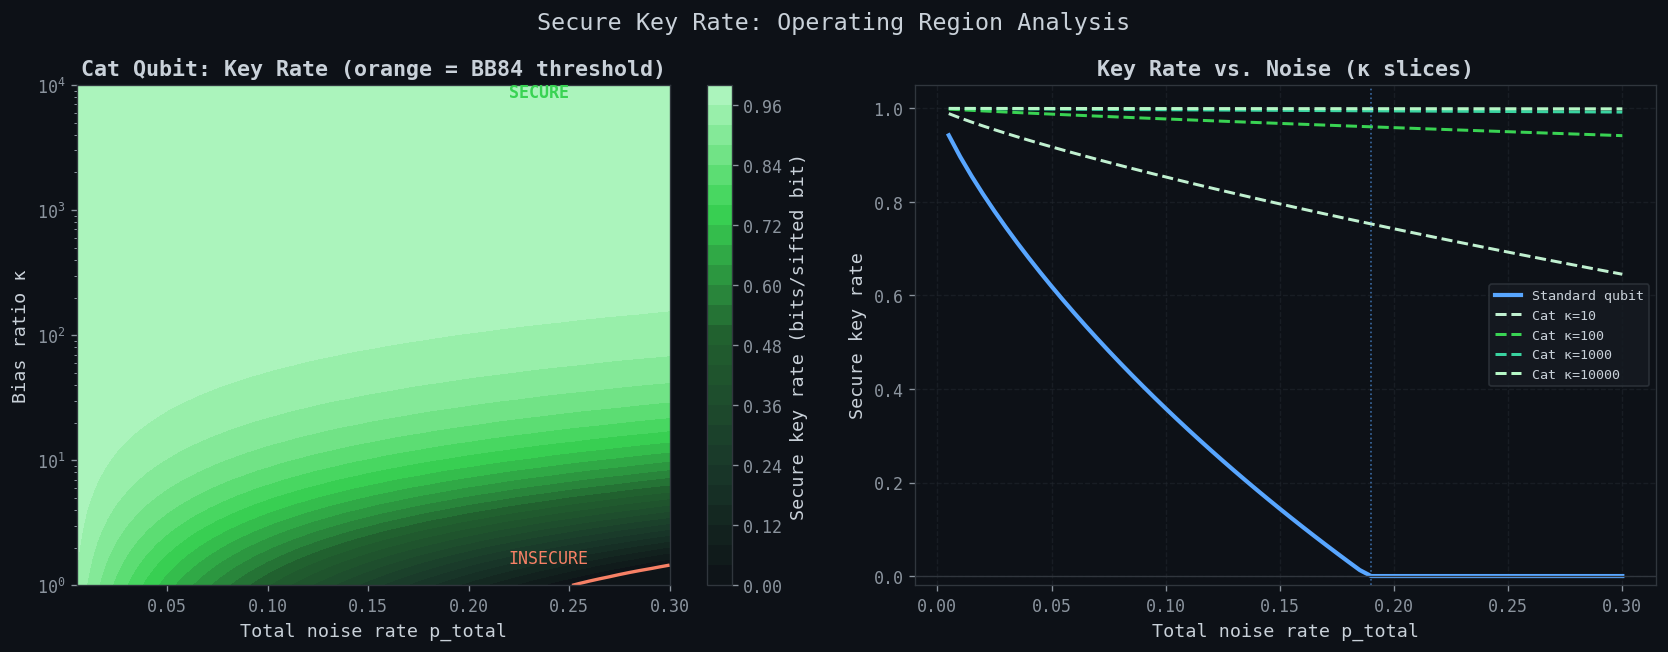

In [ ]:
def h2(p):
    p = np.clip(p, 1e-10, 1 - 1e-10)
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

def qber_cat_analytic(p_total, kappa):
    """
    Approximate analytic QBER for cat qubit proxy.
    In BB84, bit-flip errors (X) cause QBER in Z-basis,
    and phase-flip errors (Z) cause QBER in X-basis.
    Overall QBER ≈ average of both basis QBERs.
    """
    p_x = p_total / (2 * (kappa + 1))
    p_z = p_total * kappa / (kappa + 1)
    
    p_meas = (p_total / 2) / (kappa + 1)
    qber_z = np.clip(p_x + p_meas, 0, 0.5)
    qber_x = np.clip(p_z / (kappa * 2 + 2) + p_meas, 0, 0.5)
    return (qber_z + qber_x) / 2

def qber_std_analytic(p_total):
    p_meas = p_total / 2
    return np.clip(p_total / 3 + p_meas / 2, 0, 0.5)

P_GRID  = np.linspace(0.005, 0.30, 60)
K_GRID  = np.logspace(0, 4, 60)
PP, KK  = np.meshgrid(P_GRID, K_GRID)

QBER_CAT = qber_cat_analytic(PP, KK)
KEY_RATE_CAT = np.maximum(0, 1 - 2 * h2(QBER_CAT))
KEY_RATE_STD = np.maximum(0, 1 - 2 * h2(qber_std_analytic(P_GRID)))


cmap = LinearSegmentedColormap.from_list(
    'catqubit',
    ['#0d1117', '#1a3a2a', '#21602f', '#39d353', '#b5f7c5'],
    N=256
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Secure Key Rate: Operating Region Analysis', fontsize=14, color='#c9d1d9')

im = ax1.contourf(PP, KK, KEY_RATE_CAT, levels=30, cmap=cmap)
ax1.contour(PP, KK, QBER_CAT, levels=[BB84_THRESHOLD], colors=[ACCENT_ORANGE], linewidths=2)
ax1.set_yscale('log')
ax1.set_xlabel('Total noise rate p_total')
ax1.set_ylabel('Bias ratio k')
ax1.set_title(f'Cat Qubit: Key Rate (orange = BB84 threshold)')
plt.colorbar(im, ax=ax1, label='Secure key rate (bits/sifted bit)')
ax1.text(0.22, 8000, 'SECURE', color=ACCENT_TEAL, fontsize=10, fontweight='bold')
ax1.text(0.22, 1.5,  'INSECURE', color=ACCENT_ORANGE, fontsize=10)

ax2.plot(P_GRID, KEY_RATE_STD, color=ACCENT_BLUE, lw=2.5, label='Standard qubit')

for kv, col in [(10, '#c0f0d0'), (100, ACCENT_TEAL), (1000, '#39d3a0'), (10000, '#b5f7c5')]:
    qber_k = qber_cat_analytic(P_GRID, kv)
    key_k  = np.maximum(0, 1 - 2 * h2(qber_k))
    ax2.plot(P_GRID, key_k, lw=1.8, ls='--', color=col, label=f'Cat k={kv}')

ax2.axvline(P_GRID[np.argmax(KEY_RATE_STD < 0.001)], color=ACCENT_BLUE,
            lw=1, ls=':', alpha=0.6)
ax2.axhline(0, color='#30363d', lw=0.8)
ax2.set_xlabel('Total noise rate p_total')
ax2.set_ylabel('Secure key rate')
ax2.set_title('Key Rate vs. Noise (k slices)')
ax2.legend(fontsize=8)
ax2.grid(True)
ax2.set_ylim(-0.02, 1.05)

fig.tight_layout()
plt.savefig('plot3_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("Plot 3 saved")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/plot4_basis_breakdown.png'

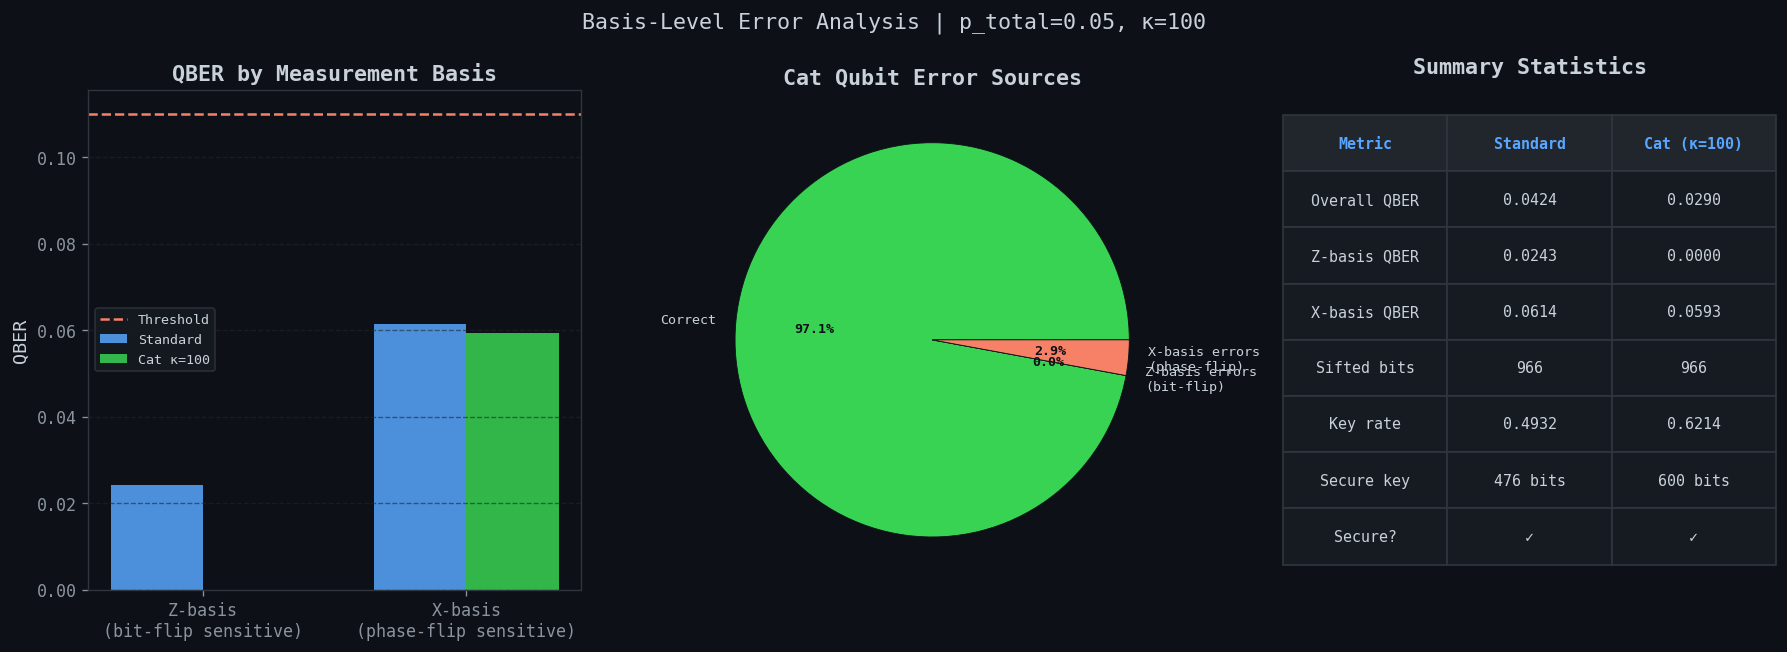

In [ ]:
def basis_breakdown(res, label):
    """
    Split the sifted key into Z-basis and X-basis components
    and compute QBER separately for each.
    """
    mask = res['sifted_mask']
    alice_b = res['alice_bases'][mask]
    alice_k = res['alice_bits'][mask]
    bob_k   = res['bob_results'][mask]

    z_mask = alice_b == 0
    x_mask = alice_b == 1

    def qber_sub(m):
        if m.sum() == 0: return 0.0
        return np.sum(alice_k[m] != bob_k[m]) / m.sum()

    return {
        'label':  label,
        'qber_z': qber_sub(z_mask),
        'qber_x': qber_sub(x_mask),
        'n_z':    z_mask.sum(),
        'n_x':    x_mask.sum(),
    }

bd_std = basis_breakdown(res_std, 'Standard qubit')
bd_cat = basis_breakdown(res_cat, f'Cat qubit (k={KAPPA})')

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.suptitle(f'Basis-Level Error Analysis | p_total={P_TOTAL}, k={KAPPA}',
             fontsize=13, color='#c9d1d9')

# bar
ax = axes[0]
x = np.arange(2)
w = 0.35
b1 = ax.bar(x - w/2, [bd_std['qber_z'], bd_std['qber_x']], w,
            color=ACCENT_BLUE, alpha=0.85, label='Standard')
b2 = ax.bar(x + w/2, [bd_cat['qber_z'],  bd_cat['qber_x']],  w,
            color=ACCENT_TEAL, alpha=0.85, label=f'Cat k={KAPPA}')
ax.axhline(BB84_THRESHOLD, color=ACCENT_ORANGE, lw=1.5, ls='--', label='Threshold')
ax.set_xticks(x)
ax.set_xticklabels(['Z-basis\n(bit-flip sensitive)', 'X-basis\n(phase-flip sensitive)'])
ax.set_ylabel('QBER')
ax.set_title('QBER by Measurement Basis')
ax.legend(fontsize=8)
ax.grid(True, axis='y')

ax = axes[1]
z_err = bd_cat['qber_z'] * bd_cat['n_z']
x_err = bd_cat['qber_x'] * bd_cat['n_x']
correct = (bd_cat['n_z'] + bd_cat['n_x']) - z_err - x_err
sizes = [correct, z_err, x_err]
labels = ['Correct', 'Z-basis errors\n(bit-flip)', 'X-basis errors\n(phase-flip)']
colors = [ACCENT_TEAL, ACCENT_BLUE, ACCENT_ORANGE]
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors, autopct='%1.1f%%',
    textprops={'fontsize': 8, 'color': '#c9d1d9'},
    wedgeprops={'linewidth': 0.5, 'edgecolor': '#0d1117'}
)
for at in autotexts:
    at.set_color('#0d1117')
    at.set_fontweight('bold')
ax.set_title(f'Cat Qubit Error Sources')

ax = axes[2]
ax.axis('off')
table_data = [
    ['Metric', 'Standard', f'Cat (k={KAPPA})'],
    ['Overall QBER', f"{res_std['qber']:.4f}", f"{res_cat['qber']:.4f}"],
    ['Z-basis QBER', f"{bd_std['qber_z']:.4f}", f"{bd_cat['qber_z']:.4f}"],
    ['X-basis QBER', f"{bd_std['qber_x']:.4f}", f"{bd_cat['qber_x']:.4f}"],
    ['Sifted bits',  str(res_std['n_sifted']),  str(res_cat['n_sifted'])],
    ['Key rate',     f"{res_std['key_rate']:.4f}",  f"{res_cat['key_rate']:.4f}"],
    ['Secure key',   f"{res_std['secure_key_len']} bits", f"{res_cat['secure_key_len']} bits"],
    ['Secure?',
     '✓' if res_std['qber'] < BB84_THRESHOLD else '✗',
     '✓' if res_cat['qber'] < BB84_THRESHOLD else '✗'],
]

tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               cellLoc='center', loc='center',
               bbox=[0.0, 0.05, 1.0, 0.9])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
for (row, col), cell in tbl.get_celld().items():
    cell.set_facecolor('#161b22')
    cell.set_edgecolor('#30363d')
    cell.set_text_props(color='#c9d1d9')
    if row == 0:
        cell.set_facecolor('#21262d')
        cell.set_text_props(color='#58a6ff', fontweight='bold')
ax.set_title('Summary Statistics', pad=10)

fig.tight_layout()
plt.savefig('plot4_basis_breakdown.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Plot 4 saved")

In [ ]:
print("FINAL SUMMARY: BB84 QKD Performance Analysis")
print(f"Simulation parameters:")
print(f"     N_qubits       = {N_QUBITS:<39}")
print(f"     p_total (demo) = {P_TOTAL:<39}")
print(f"     k (demo)       = {KAPPA:<39}")
print("-" * 60)
print(f"   Standard qubit:" + " "*43)
print(f"     QBER           = {res_std['qber']:.4f}  ({res_std['qber']*100:.2f}%)" + " "*28)
print(f"     Key rate       = {res_std['key_rate']:.4f} bits/sifted bit" + " "*23)
print(f"     Secure key     = {res_std['secure_key_len']} bits" + " "*38)
print(f"     Secure (BB84)  = {'YES' if res_std['qber']<BB84_THRESHOLD else 'NO'}" + " "*54)
print("-" * 60)
print(f"   Cat qubit (k={KAPPA}):" + " "*38)
print(f"     QBER           = {res_cat['qber']:.4f}  ({res_cat['qber']*100:.2f}%)" + " "*28)
print(f"     Key rate       = {res_cat['key_rate']:.4f} bits/sifted bit" + " "*23)
print(f"     Secure key     = {res_cat['secure_key_len']} bits" + " "*38)
print(f"     Secure (BB84)  = {'YES' if res_cat['qber']<BB84_THRESHOLD else 'NO'}" + " "*54)
print("-" * 60)
print(f"   Advantage metrics:" + " "*40)
qber_reduction = res_std['qber'] / max(res_cat['qber'], 1e-9)
key_gain = res_cat['secure_key_len'] - res_std['secure_key_len']
print(f"     QBER reduction = {qber_reduction:.1f}x" + " "*48)
print(f"     Key length gain= {key_gain:+d} bits" + " "*43)
print("-" * 60)

print()
print("k sweep summary (QBER at selected k values):")
print(f"  {'k':>8} | {'QBER':>8} | {'Key bits':>10} | {'Secure':>8}")
print(f"  {'-'*44}")
for r in sweep_results[::4]:   # Print every 4th entry
    secure = 'YES' if r['qber_mean'] < BB84_THRESHOLD else 'NO'
    print(f"  {r['kappa']:>8} | {r['qber_mean']:>8.4f} | {int(r['key_mean']):>10} | {secure:>8}")

╔════════════════════════════════════════════════════════════╗
║   FINAL SUMMARY: BB84 QKD Performance Analysis             ║
╠════════════════════════════════════════════════════════════╣
║  Simulation parameters:                                    ║
║    N_qubits       = 2000                                   ║
║    p_total (demo) = 0.05                                   ║
║    κ (demo)       = 100                                    ║
╠════════════════════════════════════════════════════════════╣
║  Standard qubit:                                           ║
║    QBER           = 0.0424  (4.24%)                            ║
║    Key rate       = 0.4932 bits/sifted bit                       ║
║    Secure key     = 476 bits                                      ║
║    Secure (BB84)  = YES ✓                                                      ║
╠════════════════════════════════════════════════════════════╣
║  Cat qubit (κ=100):                                      ║
║    QBER           